# 01 · Quem presta o ENEM?

**Pergunta:** qual é o perfil demográfico e socioeconômico dos 4,3 milhões de inscritos no ENEM 2024?

**Dados:** agregados de `PARTICIPANTES_2024.csv` (INEP), gerados por `enem2024.build_aggregates`.
O questionário socioeconômico de 2024 tem 23 questões — atenção: a renda familiar é a **Q007**
(não a Q006 como em edições anteriores) e o acesso à internet (wi-fi) é a **Q020**.

> Por decisão do INEP (LGPD), esta base **não tem chave de ligação** com a base de notas.
> Tudo aqui descreve *quem se inscreve*; desempenho é assunto dos notebooks 02–04.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from enem2024 import labels, plots
from enem2024.data import load

plots.setup()
GRAY = plots.BASELINE  # de-ênfase


In [2]:
perfil = load("perfil_participantes")
total = int(perfil["n"].sum())
fem = perfil.loc[perfil.sexo == "F", "n"].sum() / total
treineiros = perfil.loc[perfil.treineiro == 1, "n"].sum() / total
jovens = perfil.loc[perfil.faixa_etaria.isin([2, 3]), "n"].sum() / total

print(f"Inscritos:  {total:,}".replace(",", "."))
print(f"Mulheres:   {fem:.1%}")
print(f"17-18 anos: {jovens:.1%}")
print(f"Treineiros: {treineiros:.1%}")

Inscritos:  4.332.944
Mulheres:   60.6%
17-18 anos: 44.4%
Treineiros: 19.5%


## Idade: um exame de recém-concluintes — mas não só

A faixa etária modal é 18 anos, seguida de 17 (concluintes do EM). A cauda de adultos (26+) mostra o ENEM como porta de reingresso à educação superior.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


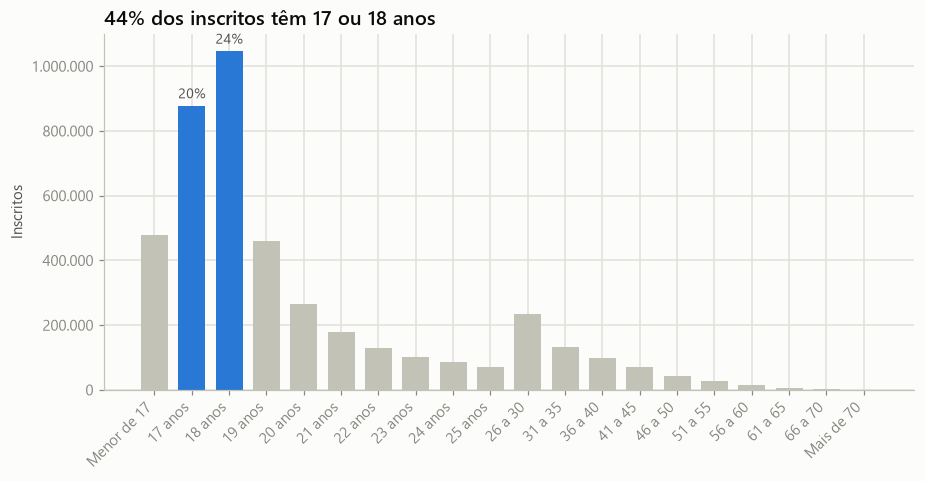

In [3]:
fx = perfil.groupby("faixa_etaria")["n"].sum().reindex(labels.ORDEM_FAIXA_ETARIA)
share = fx / fx.sum()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
colors = [plots.BLUE if i in (2, 3) else GRAY for i in fx.index]
bars = ax.bar(range(len(fx)), fx.values, color=colors, width=0.72)
ax.set_xticks(range(len(fx)))
ax.set_xticklabels([labels.FAIXA_ETARIA[i] for i in fx.index], rotation=45, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(plots.fmt_thousands))
ax.set_title("44% dos inscritos têm 17 ou 18 anos")
ax.set_ylabel("Inscritos")
# rótulo direto só nas barras em destaque
for i in (1, 2):
    ax.annotate(f"{share.iloc[i]:.0%}", (i, fx.iloc[i]), ha="center",
                va="bottom", fontsize=9, color=plots.INK_SECONDARY, xytext=(0, 3),
                textcoords="offset points")
plots.save_fig(fig, "01_faixa_etaria")
plt.show()

## Cor/raça: maioria parda e preta

Pretos + pardos: 55.3%


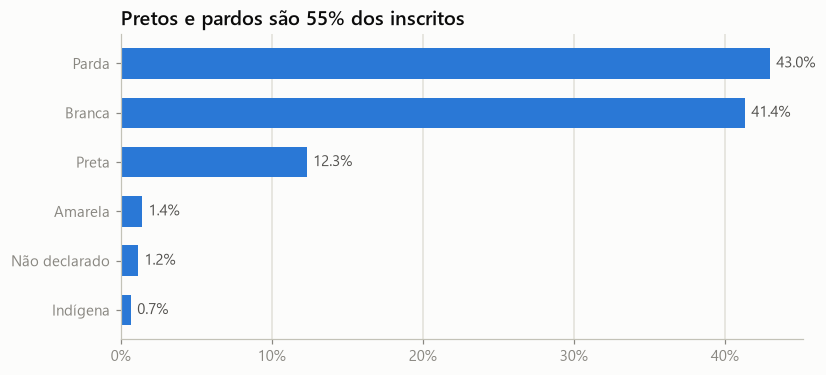

In [4]:
cr = perfil.groupby("cor_raca")["n"].sum()
cr = cr / cr.sum()
cr.index = cr.index.map(labels.COR_RACA)
cr = cr.drop(["Sem informação"], errors="ignore").sort_values()

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(cr.index, cr.values, color=plots.BLUE, height=0.62)
ax.bar_label(ax.containers[0], fmt=lambda v: f"{v:.1%}", padding=4,
             fontsize=9.5, color=plots.INK_SECONDARY)
ax.set_title("Pretos e pardos são 55% dos inscritos")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
pp = perfil.loc[perfil.cor_raca.isin([2, 3]), "n"].sum() / perfil["n"].sum()
print(f"Pretos + pardos: {pp:.1%}")
plt.show()

## Renda familiar (Q007): o retrato da desigualdade na entrada

As alternativas do INEP acompanham múltiplos do salário mínimo de 2024 (R$ 1.412).

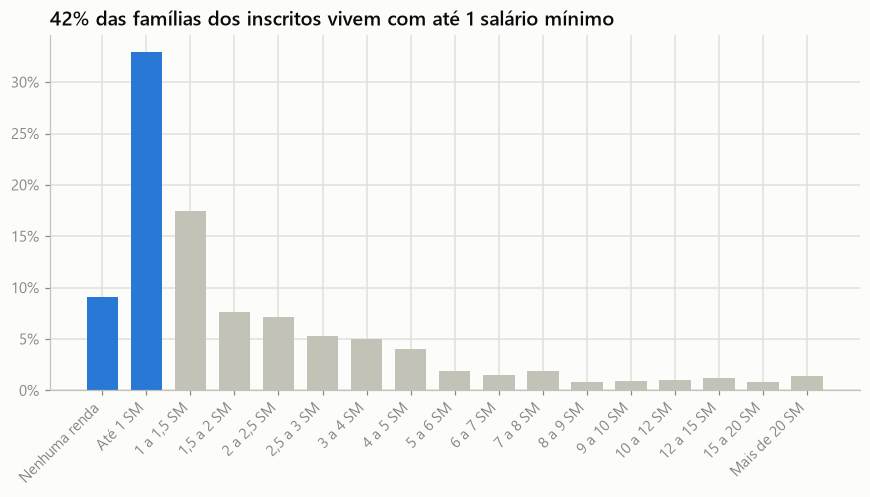

In [5]:
socio = load("socio_participantes")

renda = socio.dropna(subset=["renda"]).groupby("renda")["n"].sum()
renda = (renda / renda.sum()).reindex(labels.ORDEM_RENDA)
ate_1sm = renda[["A", "B"]].sum()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
colors = [plots.BLUE if k in ("A", "B") else GRAY for k in renda.index]
ax.bar(range(len(renda)), renda.values, color=colors, width=0.72)
ax.set_xticks(range(len(renda)))
ax.set_xticklabels([labels.RENDA[k] for k in renda.index], rotation=45, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"{ate_1sm:.0%} das famílias dos inscritos vivem com até 1 salário mínimo")
plots.save_fig(fig, "02_renda")
plt.show()

## Escolaridade da mãe (Q002)

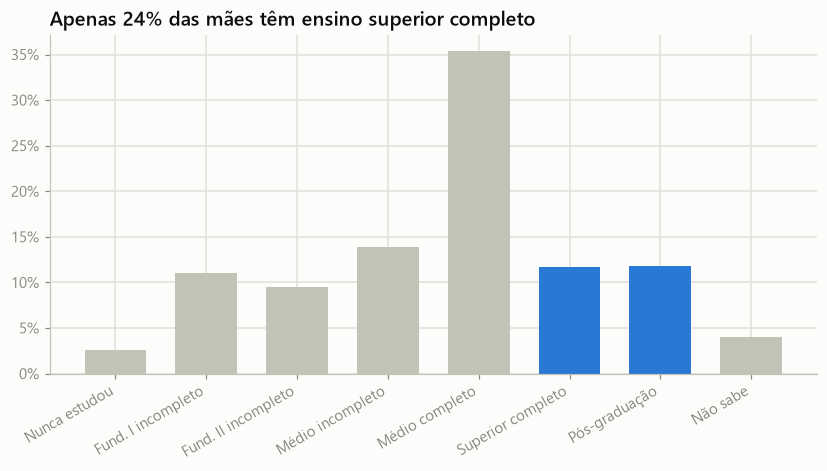

In [6]:
esc = socio.dropna(subset=["escolaridade_mae"]).groupby("escolaridade_mae")["n"].sum()
esc = (esc / esc.sum()).reindex(labels.ORDEM_ESCOLARIDADE)
superior = esc[["F", "G"]].sum()

fig, ax = plt.subplots(figsize=(9, 4))
colors = [plots.BLUE if k in ("F", "G") else GRAY for k in esc.index]
ax.bar(range(len(esc)), esc.values, color=colors, width=0.68)
ax.set_xticks(range(len(esc)))
ax.set_xticklabels([labels.ESCOLARIDADE[k] for k in esc.index], rotation=30, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"Apenas {superior:.0%} das mães têm ensino superior completo")
plt.show()

## Quatro indicadores que resumem a barreira socioeconômica

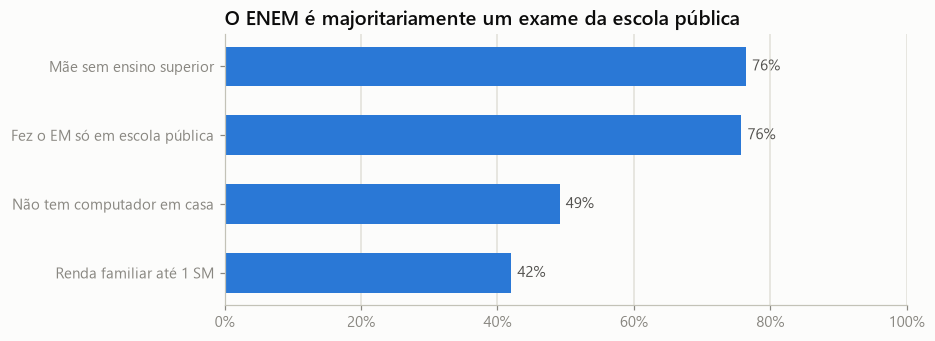

In [7]:
def share(col, vals):
    d = socio.dropna(subset=[col])
    return d.loc[d[col].isin(vals), "n"].sum() / d["n"].sum()

ind = pd.Series({
    "Fez o EM só em escola pública": share("tipo_escola_em", ["A"]),
    "Não tem computador em casa": share("computador", ["A"]),
    "Renda familiar até 1 SM": share("renda", ["A", "B"]),
    "Mãe sem ensino superior": 1 - share("escolaridade_mae", ["F", "G"]),
}).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(ind.index, ind.values, color=plots.BLUE, height=0.58)
ax.bar_label(ax.containers[0], fmt=lambda v: f"{v:.0%}", padding=4,
             fontsize=10, color=plots.INK_SECONDARY)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("O ENEM é majoritariamente um exame da escola pública")
ax.grid(axis="y", visible=False)
plots.save_fig(fig, "03_indicadores_socio")
plt.show()

## Conclusões

1. **4.332.944 inscritos**; 60,6% mulheres; 44,4% com 17–18 anos; 19,5% treineiros.
2. **Pretos e pardos são 55,3%** dos inscritos (pardos 43,0%, pretos 12,3%, brancos 41,4%).
3. **42% das famílias vivem com até 1 salário mínimo**; só 11,4% ganham acima de 5 SM.
4. **76% estudaram o Ensino Médio apenas em escola pública**; 49% não têm computador em casa;
   só 23,6% das mães completaram o ensino superior.

O público do ENEM é jovem, feminino, majoritariamente preto/pardo e de baixa renda —
contexto indispensável para ler os resultados dos próximos notebooks.